In [1]:
import pandas as pd
import kagglehub
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import umap
import warnings
warnings.filterwarnings('ignore')

path = kagglehub.dataset_download("nathansmallcalder/lol-match-history-and-summoner-data-80k-matches")

df_team  = pd.read_csv(f"{path}/TeamMatchTbl.csv")
df_champ = pd.read_csv(f"{path}/ChampionTbl.csv")

print(f"Team rows  : {len(df_team)}")
print(f"Champ rows : {len(df_champ)}")

100%|██████████| 41.3M/41.3M [00:00<00:00, 164MB/s]

Extracting files...


Team rows  : 214330
Champ rows : 173


In [2]:
# Check what queue types exist in the match table
df_match = pd.read_csv(f"{path}/MatchTbl.csv")
print(df_match['QueueType'].value_counts())

QueueType
CLASSIC      190788
ARAM          58799
CHERRY        18927
SWIFTPLAY      9620
URF            1239
ULTBOOK          14
Name: count, dtype: int64


In [3]:
classic_matches = df_match[df_match['QueueType'] == 'CLASSIC']['MatchId'].tolist()
classic_match_set = set(classic_matches)

print(f"Total matches      : {len(df_match)}")
print(f"Classic matches    : {len(classic_matches)}")

df_team_classic = df_team[df_team['MatchFk'].isin(classic_match_set)].reset_index(drop=True)
print(f"Team rows (classic): {len(df_team_classic)}")

Total matches      : 279423
Classic matches    : 190788
Team rows (classic): 149717


In [4]:
champ_lookup = dict(zip(df_champ['ChampionId'], df_champ['ChampionName']))
valid_champ_ids = sorted([cid for cid in champ_lookup if cid != 0])
champ_names     = [champ_lookup[cid] for cid in valid_champ_ids]

print(f"Valid champions: {len(valid_champ_ids)}")

Valid champions: 172


In [5]:
#encode
blue_cols = ['B1Champ', 'B2Champ', 'B3Champ', 'B4Champ', 'B5Champ']
red_cols  = ['R1Champ', 'R2Champ', 'R3Champ', 'R4Champ', 'R5Champ']

def encode_side_fast(df, pick_cols, prefix):
    result = pd.DataFrame(0, index=df.index,
                          columns=[f"{prefix}_{name}" for name in champ_names],
                          dtype=np.int8)
    for col in pick_cols:
        for cid, name in zip(valid_champ_ids, champ_names):
            result.loc[df[col] == cid, f"{prefix}_{name}"] = 1
    return result

print("Encoding blue side (Classic only)...")
blue_encoded = encode_side_fast(df_team_classic, blue_cols, "Blue")
print("Encoding red side (Classic only)...")
red_encoded  = encode_side_fast(df_team_classic, red_cols,  "Red")
print("Done.")
print(f"Encoded shape: {blue_encoded.shape}")

Encoding blue side (Classic only)...
Encoding red side (Classic only)...
Done.
Encoded shape: (149717, 172)


In [19]:
blue_sums = blue_encoded.sum(axis=1)
red_sums  = red_encoded.sum(axis=1)
mask      = (blue_sums == 5) & (red_sums == 5)

blue_encoded    = blue_encoded[mask].reset_index(drop=True)
red_encoded     = red_encoded[mask].reset_index(drop=True)
df_team_classic = df_team_classic[mask].reset_index(drop=True)
labels          = df_team_classic[['RedWin', 'BlueWin']].copy()

X_champs = pd.concat([blue_encoded, red_encoded], axis=1)

print(f"Rows after filter : {len(X_champs)}")
print(f"Feature matrix    : {X_champs.shape}")
print(f"Labels            : {labels.shape}")

Rows after filter : 149717
Feature matrix    : (149717, 344)
Labels            : (149717, 2)


In [20]:
blue_team = blue_encoded.rename(columns=lambda c: c.replace("Blue_", ""))
red_team  = red_encoded.rename(columns=lambda c: c.replace("Red_",  ""))

blue_team = blue_team.copy()
red_team  = red_team.copy()

blue_team["Win"] = df_team_classic["BlueWin"].values
red_team["Win"]  = df_team_classic["RedWin"].values

per_team_df = pd.concat([blue_team, red_team], ignore_index=True)
X_pt = per_team_df[champ_names].astype(np.int8)
y_pt = per_team_df["Win"].astype(np.int8)

print(f"Per-team rows    : {len(per_team_df):,}")
print(f"Feature columns  : {X_pt.shape[1]}")
print(f"Overall win rate : {y_pt.mean():.1%}  (should be ~50%)")


Per-team rows    : 299,434
Feature columns  : 172
Overall win rate : 50.0%  (should be ~50%)


In [8]:
#UMAP on per-team comps
PT_SAMPLE   = 60_000
RANDOM_SEED = 42

rng    = np.random.default_rng(RANDOM_SEED)
pt_idx = rng.choice(len(X_pt), PT_SAMPLE, replace=False)
X_pt_s = X_pt.iloc[pt_idx].reset_index(drop=True)
y_pt_s = y_pt.iloc[pt_idx].reset_index(drop=True)

reducer_pt = umap.UMAP(
    n_components = 2,
    n_neighbors  = 25,
    min_dist     = 0.05,
    metric       = "jaccard",
    random_state = RANDOM_SEED,
    verbose      = True,
)

print("Fitting UMAP on per-team compositions (60k rows) ...")
X_pt_umap = reducer_pt.fit_transform(X_pt_s.values)
print(f"Done.  Shape: {X_pt_umap.shape}")


Fitting UMAP on per-team compositions (60k rows) ...
UMAP(angular_rp_forest=True, metric='jaccard', min_dist=0.05, n_jobs=1, n_neighbors=25, random_state=42, verbose=True)
Thu May  7 13:20:18 2026 Construct fuzzy simplicial set
Thu May  7 13:20:18 2026 Finding Nearest Neighbors
Thu May  7 13:20:18 2026 Building RP forest with 17 trees
Thu May  7 13:20:24 2026 NN descent for 16 iterations
	 1  /  16
	 2  /  16
	 3  /  16
	 4  /  16
	 5  /  16
	 6  /  16
	Stopping threshold met -- exiting after 6 iterations
Thu May  7 13:21:03 2026 Finished Nearest Neighbor Search
Thu May  7 13:21:09 2026 Construct embedding


Epochs completed:   0%|            0/200 [00:00]

	completed  0  /  200 epochs
	completed  20  /  200 epochs
	completed  40  /  200 epochs
	completed  60  /  200 epochs
	completed  80  /  200 epochs
	completed  100  /  200 epochs
	completed  120  /  200 epochs
	completed  140  /  200 epochs
	completed  160  /  200 epochs
	completed  180  /  200 epochs
Thu May  7 13:23:21 2026 Finished embedding
Done.  Shape: (60000, 2)


In [9]:
#HDBSCAN clustering on per-team UMAP
import hdbscan

clusterer_pt = hdbscan.HDBSCAN(
    min_cluster_size          = 1000,
    min_samples               = 15,
    cluster_selection_epsilon = 0.0,
)
pt_labels = clusterer_pt.fit_predict(X_pt_umap)

n_clusters = len(set(pt_labels)) - (1 if -1 in pt_labels else 0)
n_noise    = (pt_labels == -1).sum()
print(f"Clusters found : {n_clusters}")
print(f"Noise points   : {n_noise:,}  ({n_noise/len(pt_labels):.1%})")
print()
for c in sorted(set(pt_labels)):
    tag = "  noise" if c == -1 else f"cluster {c:>2}"
    print(f"  {tag}: {(pt_labels == c).sum():>6,}")


Clusters found : 16
Noise points   : 3,990  (6.7%)

    noise:  3,990
  cluster  0:  4,092
  cluster  1:  4,514
  cluster  2:  3,685
  cluster  3:  2,688
  cluster  4:  3,690
  cluster  5:  4,648
  cluster  6:  3,576
  cluster  7:  2,383
  cluster  8:  5,502
  cluster  9:  2,855
  cluster 10:  2,066
  cluster 11:  1,054
  cluster 12:  1,855
  cluster 13:  1,875
  cluster 14:  3,247
  cluster 15:  8,280


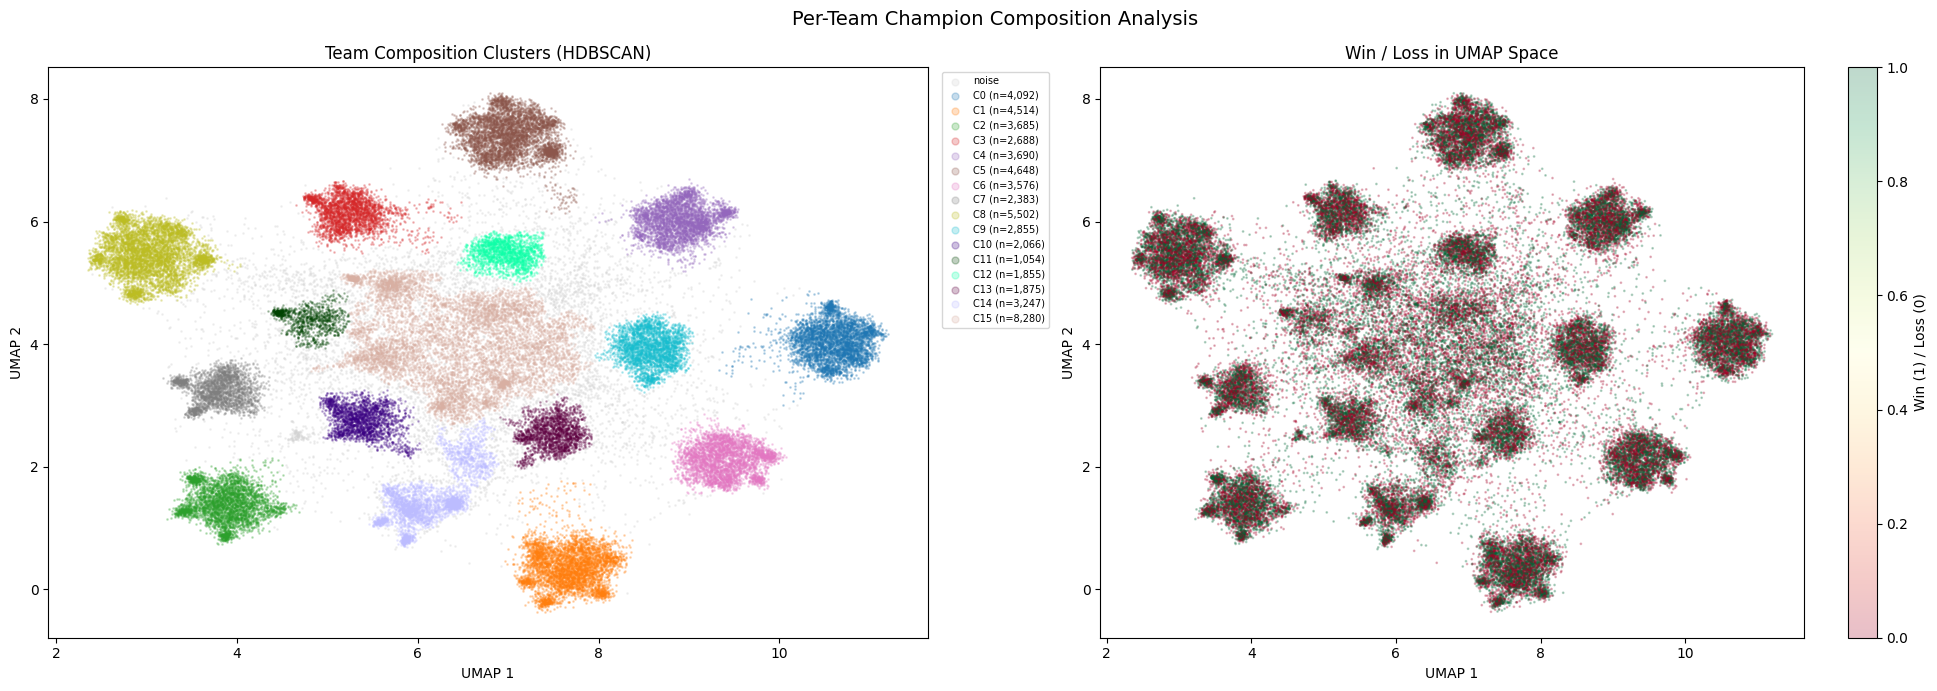

In [10]:
import colorcet as cc

palette = list(cc.glasbey_category10)

fig, axes = plt.subplots(1, 2, figsize=(20, 7))

# Left: cluster membership
ax = axes[0]
for c in sorted(set(pt_labels)):
    m     = pt_labels == c
    color = "lightgray" if c == -1 else palette[c % len(palette)]
    lbl   = "noise" if c == -1 else f"C{c} (n={m.sum():,})"
    ax.scatter(X_pt_umap[m, 0], X_pt_umap[m, 1],
               s=1, alpha=0.25, color=color, label=lbl)
ax.set_title("Team Composition Clusters (HDBSCAN)", fontsize=12)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
ax.legend(markerscale=5, fontsize=7, loc="upper left",
          bbox_to_anchor=(1.01, 1), ncol=1)

# Right: win / loss scatter
ax = axes[1]
sc = ax.scatter(X_pt_umap[:, 0], X_pt_umap[:, 1],
                c=y_pt_s.values, cmap="RdYlGn",
                s=1, alpha=0.25, vmin=0, vmax=1)
plt.colorbar(sc, ax=ax, label="Win (1) / Loss (0)")
ax.set_title("Win / Loss in UMAP Space", fontsize=12)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")

plt.suptitle("Per-Team Champion Composition Analysis", fontsize=14)
plt.tight_layout()
plt.savefig("umap_per_team.png", dpi=150)
plt.show()


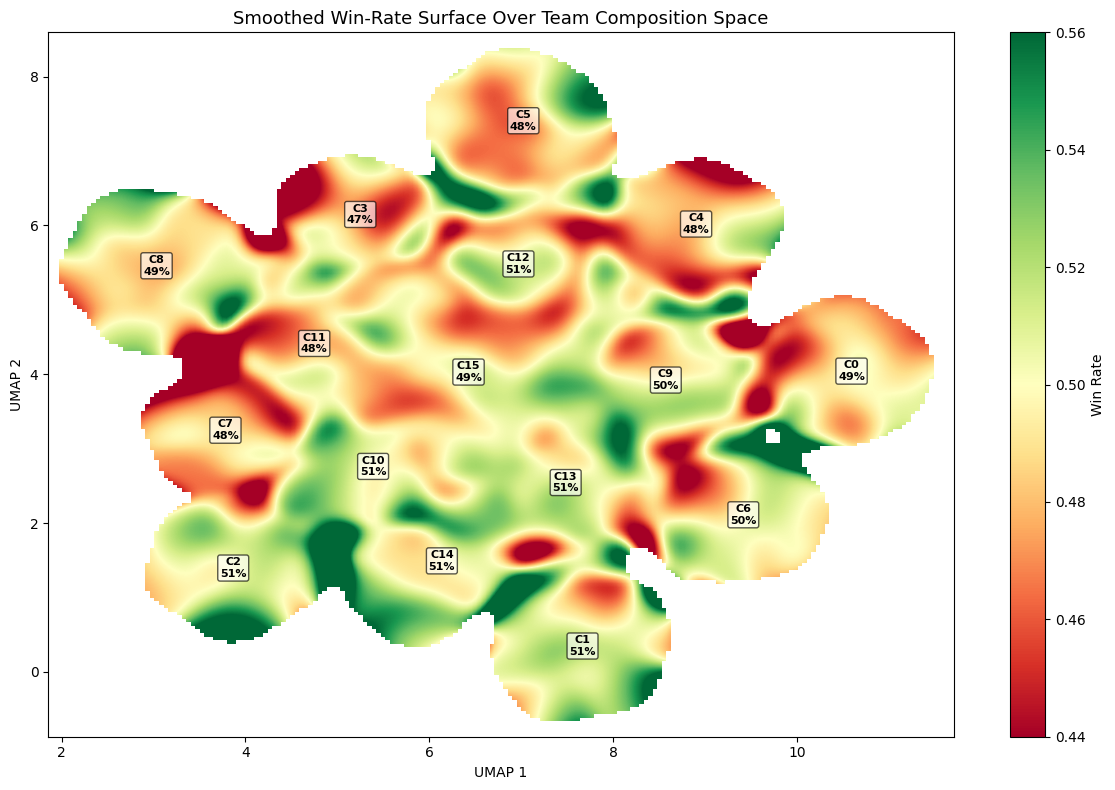

In [11]:
import numpy as np
from scipy.ndimage import gaussian_filter
from statsmodels.stats.proportion import proportion_confint

grid_res = 200
xv, yv   = X_pt_umap[:, 0], X_pt_umap[:, 1]
x_min, x_max = xv.min() - .5, xv.max() + .5
y_min, y_max = yv.min() - .5, yv.max() + .5

xi_idx = np.clip(((xv - x_min) / (x_max - x_min) * (grid_res-1)).astype(int), 0, grid_res-1)
yi_idx = np.clip(((yv - y_min) / (y_max - y_min) * (grid_res-1)).astype(int), 0, grid_res-1)

win_grid   = np.zeros((grid_res, grid_res))
count_grid = np.zeros((grid_res, grid_res))
for xi_i, yi_i, w in zip(xi_idx, yi_idx, y_pt_s.values):
    win_grid[yi_i, xi_i]   += w
    count_grid[yi_i, xi_i] += 1

win_s   = gaussian_filter(win_grid,   sigma=4)
count_s = gaussian_filter(count_grid, sigma=4)
wr_surf = np.where(count_s > 0.1, win_s / count_s, np.nan)

fig, ax = plt.subplots(figsize=(12, 8))
img = ax.imshow(wr_surf, origin="lower",
                extent=[x_min, x_max, y_min, y_max],
                cmap="RdYlGn", vmin=0.44, vmax=0.56,
                aspect="auto", interpolation="bilinear")
plt.colorbar(img, ax=ax, label="Win Rate")

for c in sorted(set(pt_labels)):
    if c == -1:
        continue
    m  = pt_labels == c
    cx = X_pt_umap[m, 0].mean()
    cy = X_pt_umap[m, 1].mean()
    wr = y_pt_s[m].mean()
    ax.text(cx, cy, f"C{c}\n{wr:.0%}", fontsize=8, ha="center", va="center",
            fontweight="bold", color="black",
            bbox=dict(boxstyle="round,pad=0.2", fc="white", alpha=0.65))

ax.set_title("Smoothed Win-Rate Surface Over Team Composition Space", fontsize=13)
ax.set_xlabel("UMAP 1"); ax.set_ylabel("UMAP 2")
plt.tight_layout()
plt.savefig("winrate_surface.png", dpi=150)
plt.show()


In [18]:
cluster_rows = []
for c in sorted(set(pt_labels)):
    if c == -1:
        continue
    m       = pt_labels == c
    wins_c  = y_pt_s[m]
    champ_c = X_pt_s[m]
    n       = int(m.sum())
    wr      = float(wins_c.mean())
    lo, hi  = proportion_confint(int(wins_c.sum()), n, alpha=0.05, method="wilson")

    # Enrichment: pick rate in cluster vs overall
    enrichment = (champ_c.mean() - X_pt_s.mean()).sort_values(ascending=False)
    top5 = enrichment.head(5).index.tolist()

    cluster_rows.append(dict(cluster=c, n=n, win_rate=wr, ci_lo=lo, ci_hi=hi, top_champs=top5))

summary_df = pd.DataFrame(cluster_rows).sort_values("win_rate", ascending=False)

print(f"{'C':>3}  {'n':>6}  {'WR':>6}  {'95% CI':^17}  Top defining champions")
print("─" * 78)
for _, row in summary_df.iterrows():
    ci     = f"[{row['ci_lo']:.1%}, {row['ci_hi']:.1%}]"
    champs = ", ".join(row["top_champs"])
    print(f"{int(row['cluster']):>3}  {int(row['n']):>6}  {row['win_rate']:.1%}  {ci:^17}  {champs}")



  C       n      WR       95% CI        Top defining champions
──────────────────────────────────────────────────────────────────────────────
 12    1855  51.4%   [49.2%, 53.7%]    Sivir, Yuumi, Sona, Bard, Lulu
 10    2066  51.4%   [49.2%, 53.6%]    Tristana, Lulu, Leona, Nautilus, Qiyana
  2    3685  51.3%   [49.7%, 52.9%]    Jinx, Lulu, Thresh, Milio, Jax
  1    4514  51.1%   [49.6%, 52.6%]    MissFortune, Leona, Amumu, Nautilus, Sett
 14    3247  50.7%   [49.0%, 52.4%]    Lucian, Nami, Braum, Milio, Yuumi
 13    1875  50.7%   [48.5%, 53.0%]    Vayne, Lulu, Milio, Yuumi, Soraka
  9    2855  50.0%   [48.2%, 51.9%]    Smolder, Nami, Soraka, Bard, Malphite
  6    3576  49.7%   [48.1%, 51.4%]    Ashe, Seraphine, Braum, Milio, Lulu
 15    8280  49.3%   [48.2%, 50.4%]    Draven, Varus, Samira, Twitch, Zeri
  8    5502  49.1%   [47.8%, 50.4%]    Kaisa, Nautilus, Blitzcrank, Pyke, Neeko
  0    4092  48.9%   [47.3%, 50.4%]    Jhin, Xerath, Zyra, Bard, Velkoz
  7    2383  48.2%   [46.2%, 50.2